# NBA Player Clustering with Unsupervised Learning

### Dataset
We use NBA Advanced Player Stats (https://www.basketball-reference.com/leagues/NBA_2025_advanced.html).
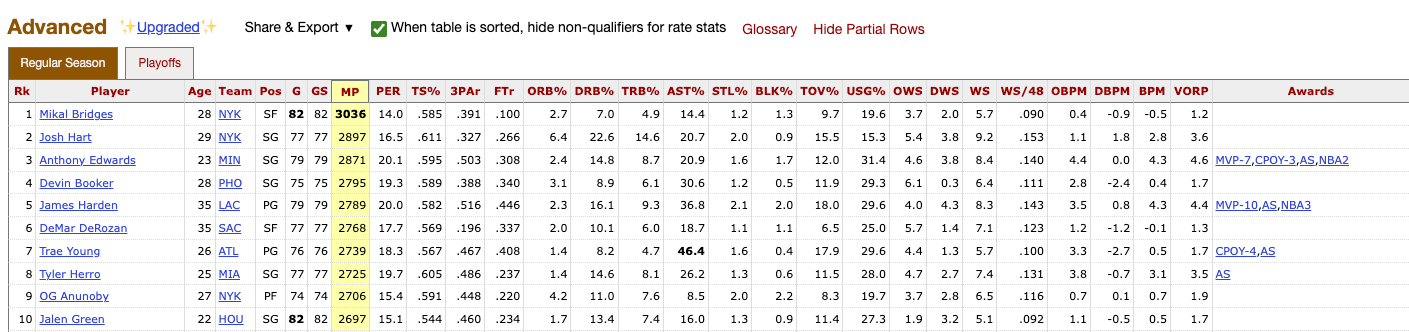

### Goal
Group NBA players into **three archetypes** based on their advanced stats:
- **Interior Enforcers** — dominate rebounding, blocking, and scoring inside.
- **Star Playmakers** — efficient scorers who also create offense for teammates.
- **Floor Spacers** — perimeter players who stretch defenses with shooting.

### Why Clustering?
Instead of labeling players manually, we let the data decide the natural groupings.  
Unsupervised learning (KMeans + PCA) helps us:
- Reduce redundancy in correlated stats (via PCA).
- Separate players into clusters that highlight their true impact.

### Purpose
This analysis shows how **data can separate stars from role players**:
- **Stars** put up high efficiency and all-around production, justifying max contracts.
- **Role Players** still contribute (defense, rebounding, shooting) but don’t carry teams the same way.

By simplifying into a few easy-to-read archetypes, coaches, analysts, and fans can quickly spot which players drive winning — and why they deserve different roles or salaries.
# Advanced NBA Stats Glossary:

 Age   -- Player's age on February 1 of the season
 
 Rk    -- Rank
 
 Age   -- Player's age on February 1 of the season
 
 Pos   -- Position
 
 G     -- Games
 
 GS    -- Games Started
 
 MP    -- Minutes Played
 
 Pos   -- Position
 
 G     -- Games
 
 GS    -- Games Started
 
 MP    -- Minutes Played

 PER   -- Player Efficiency Rating
          A measure of per-minute production standardized to league avg = 15.

 TS%   -- True Shooting Percentage
          Shooting efficiency using 2P, 3P, and FT.

 3PAr  -- 3-Point Attempt Rate
          % of FG Attempts from 3-Point Range.

 FTr   -- Free Throw Attempt Rate
          of FT Attempts per FG Attempt.

 ORB%  -- Offensive Rebound Percentage
 DRB%  -- Defensive Rebound Percentage
 TRB%  -- Total Rebound Percentage
          Estimated % of available rebounds grabbed.

 AST%  -- Assist Percentage
         Estimated % of teammate FGs assisted.

 STL%  -- Steal Percentage
 BLK%  -- Block Percentage
          Estimated % of possessions/FGs ending with a steal or block.

 TOV%  -- Turnover Percentage
          Turnovers per 100 plays.

 USG%  -- Usage Percentage
          % of team plays used while on the floor.

 OWS   -- Offensive Win Shares
 DWS   -- Defensive Win Shares
 WS    -- Win Shares
 WS/48 -- Win Shares per 48 minutes (league avg ≈ 0.100).

 OBPM  -- Offensive Box Plus/Minus
 DBPM  -- Defensive Box Plus/Minus
 BPM   -- Box Plus/Minus
          Estimated pts/100 possessions above a league-average player.

 VORP  -- Value Over Replacement Player
          Estimated pts/100 TEAM possessions above replacement (-2.0).
          Prorated to an 82-game season.


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
!conda install -y lxml


# Load dataset
url = "https://www.basketball-reference.com/leagues/NBA_2025_advanced.html#advanced"  # your link
tables = pd.read_html(url)   # grabs all tables on the page
df = tables[0]               # usually the first table

df.head()

Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneecting package metadata (repodata.json): - 
doneing environment: | 

# All requested packages already installed.



,Rk,Player,Age,Team,Pos,G,GS,MP,PER,TS%,...,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Awards
0,1.0,Mikal Bridges,28.0,NYK,SF,82.0,82.0,3036.0,14.0,0.585,...,19.6,3.7,2.0,5.7,0.090,0.4,-0.9,-0.5,1.2,NaN
1,2.0,Josh Hart,29.0,NYK,SG,77.0,77.0,2897.0,16.5,0.611,...,15.3,5.4,3.8,9.2,0.153,1.1,1.8,2.8,3.6,NaN
2,3.0,Anthony Edwards,23.0,MIN,SG,79.0,79.0,2871.0,20.1,0.595,...,31.4,4.6,3.8,8.4,0.140,4.4,0.0,4.3,4.6,"MVP-7,CPOY-3,AS,NBA2"
3,4.0,Devin Booker,28.0,PHO,SG,75.0,75.0,2795.0,19.3,0.589,...,29.3,6.1,0.3,6.4,0.111,2.8,-2.4,0.4,1.7,NaN
4,5.0,James Harden,35.0,LAC,PG,79.0,79.0,2789.0,20.0,0.582,...,29.6,4.0,4.3,8.3,0.143,3.5,0.8,4.3,4.4,"MVP-10,AS,NBA3"


## Exploratory Data Analysis (EDA)

In [45]:

#Find duplicates How many duplicated rows exist in the df? 
duplicate_rows = df.duplicated().sum()
print(f"There are {duplicate_rows} duplicate rows.")
#Finding Missing Values for all columns.
total_missing_values = df.isnull().sum().sum()
print(f"There are {total_missing_values} missing values in total.")
df.shape

There are 0 duplicate rows.
There are 714 missing values in total.


(736, 29)

In [46]:
# Keep one row per player, preferring combined-season lines like '2TM', '3TM'
df = (
    df.assign(_multi=df['Team'].str.contains('TM', na=False))  # True for 2TM/3TM
      .sort_values(['Player','_multi'], ascending=[True, False])
      .drop_duplicates(subset=['Player'], keep='first')
      .drop(columns=['_multi'])
      .reset_index(drop=True)
)


Players sometimes have multiple rows in the dataset if they played for more than one team in a season (e.g., `"2TM"`, `"3TM"`).  
To avoid double-counting the same player:

- I flagged those `"2TM"`/`"3TM"` rows as the combined-season totals.  
- I sorted so those totals appear first for each player.  
- I dropped duplicate rows, keeping only one line per player.  
- I reset the index to clean it up.

**Result:** Each player now has a single row that best represents their full-season performance.

In [47]:
#dropping  non-useful columns that are not rate based
# Keeping "Player" and "Pos" for labeling clusters later 
df.drop('Awards', axis=1, inplace=True)
df.drop('Rk', axis=1, inplace=True)
df.drop('Age',axis=1, inplace=True)
df.drop('G',axis=1, inplace=True)
df.drop('GS',axis=1, inplace=True)
# Check the DataFrame to ensure the column has been removed
df.head()

,Player,Team,Pos,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,A.J. Green,MIL,SG,1659.0,9.2,0.621,0.856,0.064,1.2,9.8,...,8.4,12.6,1.6,1.3,2.8,0.082,-1.7,-0.4,-2.2,-0.1
1,A.J. Lawson,TOR,SG,486.0,12.7,0.542,0.532,0.332,4.3,14.9,...,6.4,20.0,0.4,0.4,0.8,0.081,-1.5,-1.0,-2.5,-0.1
2,AJ Johnson,2TM,SG,639.0,7.1,0.480,0.423,0.174,1.3,8.3,...,13.2,17.4,-0.5,0.0,-0.4,-0.032,-5.6,-2.5,-8.1,-1.0
3,Aaron Gordon,DEN,PF,1447.0,17.0,0.650,0.346,0.360,6.4,12.1,...,11.3,19.0,3.6,0.7,4.3,0.143,2.7,-1.5,1.2,1.2
4,Aaron Holiday,HOU,PG,792.0,12.2,0.594,0.675,0.153,1.7,8.9,...,11.5,16.8,1.2,0.8,2.0,0.122,-0.4,0.1,-0.2,0.3


#### I kept minutes played(MP) so I can filter out those players that dont play significant minutes.

In [48]:
df2 = df.copy()
df2 = df2[df2['MP'] >= 800].reset_index(drop=True)

print("Players before filter:", len(df))
print("Players after filter (>=800 MP):", len(df2))

Players before filter: 570
Players after filter (>=800 MP): 303


In [49]:
#checking the shape of my data after the filter 
print(df2.shape)

(303, 24)


In [50]:
#Finding Missing Values for all columns after dropping Awards,Rk,Age,G, and GS column .
total_missing_values = df2.isnull().sum().sum()
print(f"There are {total_missing_values} missing values in total.")
df2.head()

There are 0 missing values in total.


,Player,Team,Pos,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,A.J. Green,MIL,SG,1659.0,9.2,0.621,0.856,0.064,1.2,9.8,...,8.4,12.6,1.6,1.3,2.8,0.082,-1.7,-0.4,-2.2,-0.1
1,Aaron Gordon,DEN,PF,1447.0,17.0,0.650,0.346,0.360,6.4,12.1,...,11.3,19.0,3.6,0.7,4.3,0.143,2.7,-1.5,1.2,1.2
2,Aaron Nesmith,IND,SF,1123.0,14.6,0.653,0.515,0.211,3.7,13.9,...,8.2,17.4,1.9,1.0,2.9,0.126,0.0,-0.5,-0.5,0.4
3,Aaron Wiggins,OKC,SG,1744.0,16.1,0.596,0.466,0.122,5.1,12.9,...,8.3,20.3,2.7,2.7,5.4,0.148,1.3,-0.2,1.1,1.4
4,Adem Bona,PHI,C,905.0,16.5,0.714,0.005,0.521,11.1,19.9,...,20.5,14.3,1.4,0.9,2.3,0.121,-2.9,0.2,-2.7,-0.2


In [51]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  303 non-null    object 
 1   Team    303 non-null    object 
 2   Pos     303 non-null    object 
 3   MP      303 non-null    float64
 4   PER     303 non-null    float64
 5   TS%     303 non-null    float64
 6   3PAr    303 non-null    float64
 7   FTr     303 non-null    float64
 8   ORB%    303 non-null    float64
 9   DRB%    303 non-null    float64
 10  TRB%    303 non-null    float64
 11  AST%    303 non-null    float64
 12  STL%    303 non-null    float64
 13  BLK%    303 non-null    float64
 14  TOV%    303 non-null    float64
 15  USG%    303 non-null    float64
 16  OWS     303 non-null    float64
 17  DWS     303 non-null    float64
 18  WS      303 non-null    float64
 19  WS/48   303 non-null    float64
 20  OBPM    303 non-null    float64
 21  DBPM    303 non-null    float64
 22  BP

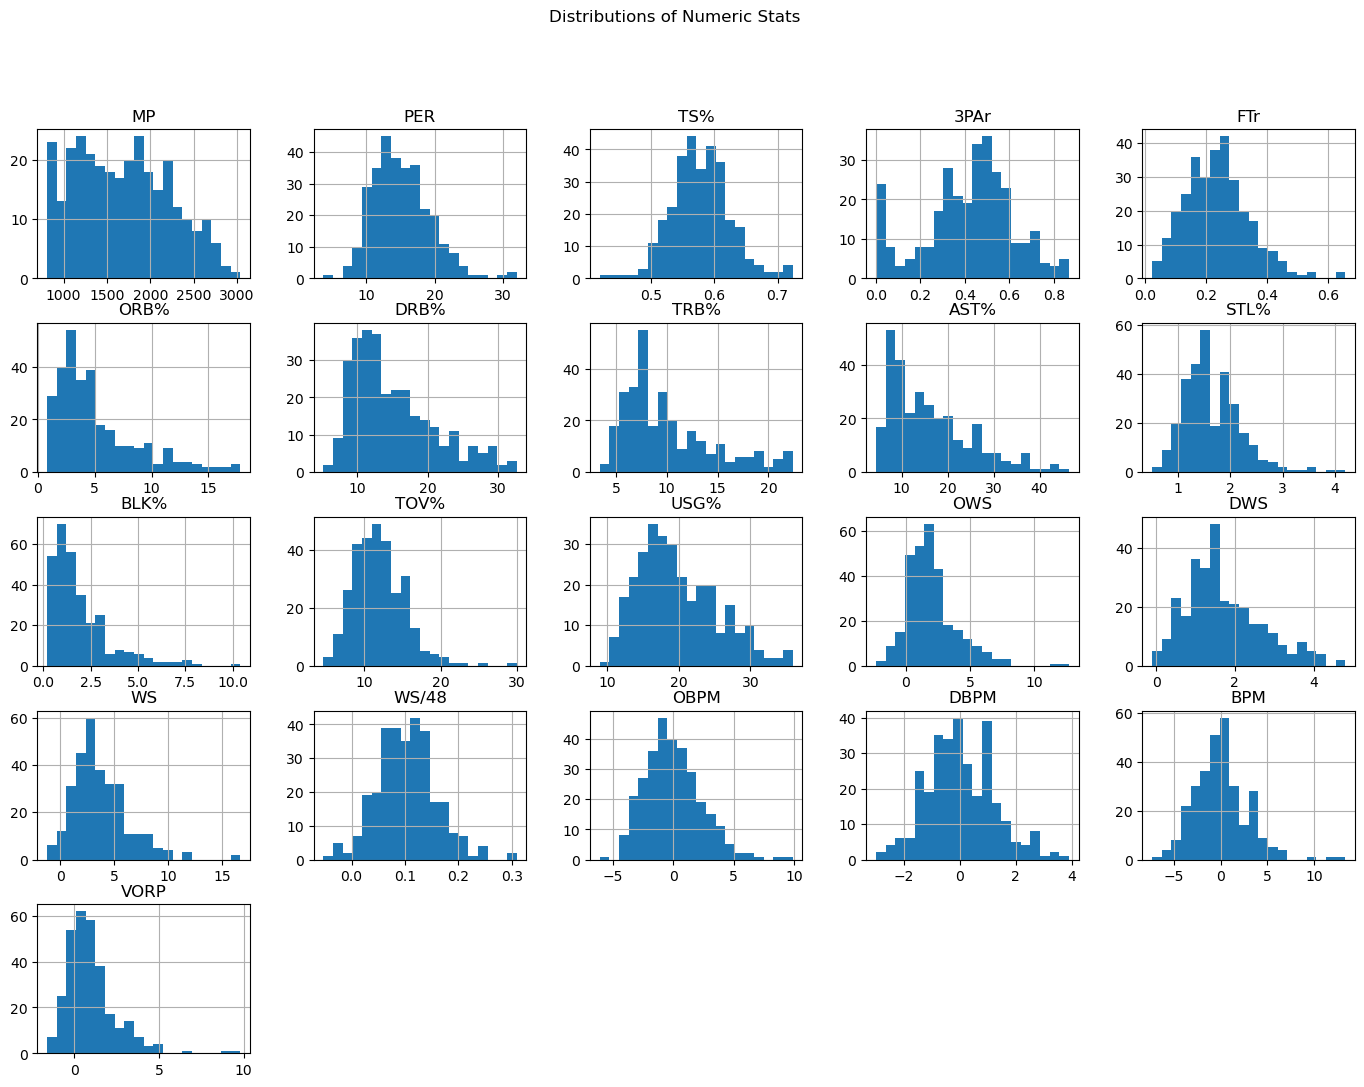

In [52]:
# Grab only numeric columns from df2
num_cols = df2.select_dtypes(include=['float64']).columns

# Now the histograms will work
df2[num_cols].hist(bins=20, figsize=(17,12))
plt.suptitle("Distributions of Numeric Stats")
plt.show()


The data shows Skewed histograms with long tails whitch often indicate outliers.

In [53]:
#checking outliers for just numerical data 
from scipy.stats import zscore

z_scores = df2[num_cols].apply(zscore)
outliers = (abs(z_scores) > 3).sum().sort_values(ascending=False)
print("Number of outliers per feature:\n", outliers)


Number of outliers per feature:
 BLK%     7
ORB%     5
STL%     5
TS%      4
AST%     4
PER      3
BPM      3
WS       3
OWS      3
TOV%     3
VORP     3
DWS      2
FTr      2
WS/48    2
OBPM     2
DBPM     1
TRB%     0
USG%     0
DRB%     0
3PAr     0
MP       0
dtype: int64


### Outlier Detection with Z-Scores

To make sure clusters are clean and not distorted by unusual players, I used **z-scores** to find outliers.  

- A **z-score** tells us how far a value is from the average, in standard deviations.  
- Players with a z-score greater than **3 or less than -3** are considered extreme outliers.  
- This is the best approach here because it works across all numeric stats and is easy to apply consistently.  

In [54]:
# Keep only rows where all z-scores are within 3 std dev
df_no_outliers = df2[(abs(z_scores) < 3).all(axis=1)].reset_index(drop=True)

print("Before:", len(df2))
print("After removing outliers:", len(df_no_outliers))


Before: 303
After removing outliers: 271


In [55]:
#checking the shape of my data after removing Outliers
print(df_no_outliers.shape)

(271, 24)


In [56]:
# checking to see tight or Big spreads(good for clustering)
df_no_outliers.describe()

,MP,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,...,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
count,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,...,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000,271.000000
mean,1687.546125,14.699262,0.577066,0.437258,0.227808,4.746494,14.654244,9.694834,15.624723,1.610701,...,11.651292,19.832103,1.905535,1.643542,3.549077,0.097845,-0.066790,-0.114022,-0.188930,0.869742
std,526.422092,3.758575,0.042067,0.190955,0.093695,3.205247,5.540415,4.077342,7.983387,0.471636,...,3.069900,5.292591,1.696316,0.915638,2.298355,0.049230,2.103965,1.072185,2.446605,1.230104
min,811.000000,7.400000,0.457000,0.000000,0.023000,0.800000,5.200000,3.400000,4.400000,0.500000,...,4.600000,9.000000,-2.300000,-0.100000,-0.900000,-0.024000,-4.500000,-3.000000,-5.700000,-1.600000
25%,1244.000000,11.850000,0.549000,0.326000,0.160000,2.500000,10.400000,6.800000,8.850000,1.300000,...,9.500000,15.800000,0.700000,1.000000,1.850000,0.065000,-1.500000,-0.800000,-1.900000,0.000000
50%,1679.000000,14.300000,0.578000,0.460000,0.229000,3.700000,13.200000,8.400000,13.900000,1.600000,...,11.400000,18.800000,1.700000,1.500000,3.000000,0.097000,-0.300000,-0.200000,-0.300000,0.600000
75%,2092.500000,17.400000,0.605000,0.555000,0.288500,5.950000,17.500000,11.800000,20.700000,1.900000,...,13.450000,23.650000,2.800000,2.200000,5.050000,0.130500,1.250000,0.700000,1.200000,1.450000
max,3036.000000,27.300000,0.704000,0.868000,0.535000,15.800000,32.600000,22.400000,40.300000,3.100000,...,21.800000,34.700000,7.400000,4.300000,10.100000,0.246000,6.400000,2.800000,7.000000,4.800000


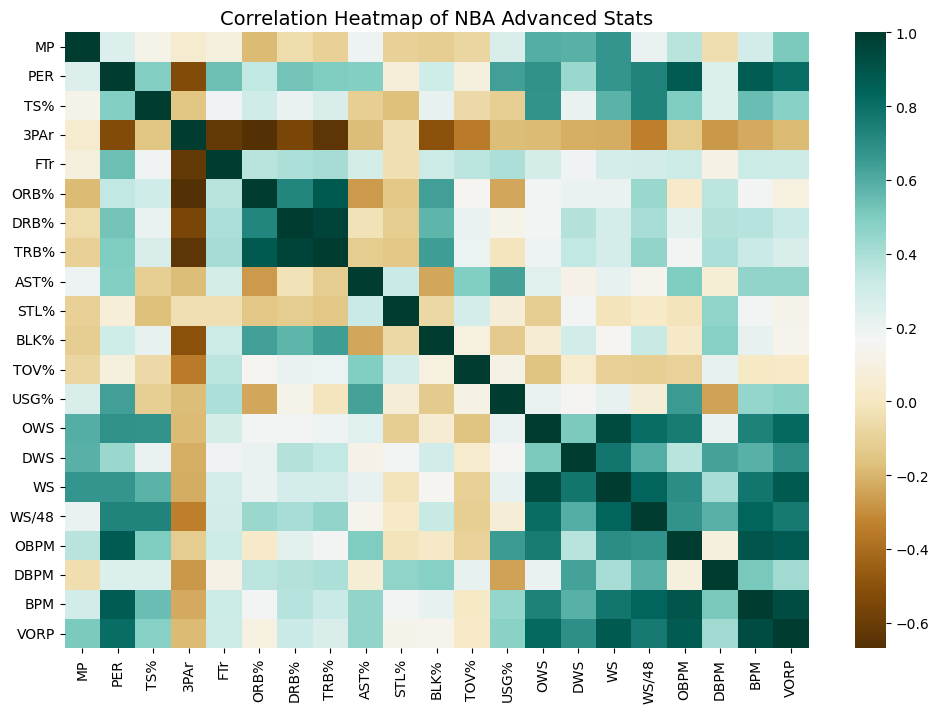

In [57]:
#correlation heatmap to see relationships for numerical stats only
# Select only numeric stats
stats_df = df_no_outliers.select_dtypes(include=['float64','int64'])

# Correlation heatmap
plt.figure(figsize=(12,8))
c = stats_df.corr()
sns.heatmap(c, cmap="BrBG", annot=False)  # annot=False keeps it cleaner for big matrices
plt.title("Correlation Heatmap of NBA Advanced Stats", fontsize=14)
plt.show()

As you can see the heatmap shows correlation between features represented by the color Green. Correlation among features can negatively influence clustering. PER% and TS% appear to be highly correlated.

## Feature Engineering & Preprocessing

In [58]:
#stats have different scales. 
# If you don’t scale, clustering will give more weight to features with larger numbers
# Select only numeric feature columns for clustering
# Select only numeric columns
features = [
    'PER','TS%','3PAr','FTr',
    'ORB%','DRB%','TRB%','AST%','STL%','BLK%','TOV%','USG%',
    'OWS','DWS','WS','WS/48',
    'OBPM','DBPM','BPM','VORP'
]

# Subset to just these features
X = df_no_outliers[features]

# Scale them so they’re on the same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame (keeps column names for readability)
X_scaled = pd.DataFrame(X_scaled, columns=features) #creating a new object so not to overwrite df_no_outliers
X_scaled.head()

       

,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,BLK%,TOV%,USG%,OWS,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP
0,-1.465831,1.046315,2.196944,-1.751555,-1.108512,-0.877773,-0.981577,-0.894095,-1.084832,-1.049306,-1.061047,-1.368986,-0.180450,-0.375889,-0.326522,-0.322455,-0.777690,-0.267218,-0.823505,-0.789800
1,0.613263,1.736974,-0.478790,1.413491,0.516829,-0.461873,-0.072444,-0.078398,-1.722093,-0.659876,-0.114643,-0.157511,1.000757,-1.032382,0.327326,0.918928,1.317469,-1.295058,0.568747,0.268977
2,-0.026458,1.808421,0.407875,-0.179725,-0.327098,-0.136387,-0.219871,-1.132529,-0.235151,-0.270446,-1.126316,-0.460380,-0.003269,-0.704135,-0.282932,0.572969,0.031803,-0.360658,-0.127379,-0.382578
3,0.373367,0.450919,0.150794,-1.131377,0.110494,-0.317213,-0.146158,-0.630562,0.189689,-0.581990,-1.093681,0.088570,0.469214,1.155928,0.806815,1.020681,0.650827,-0.080338,0.527799,0.431866
4,-0.479594,-0.335004,1.278800,-1.559086,0.141750,0.767742,0.590977,-0.655660,-1.084832,0.819959,-0.930508,-1.141835,0.055791,0.827682,0.370916,0.634020,0.079421,1.134383,0.568747,0.350421


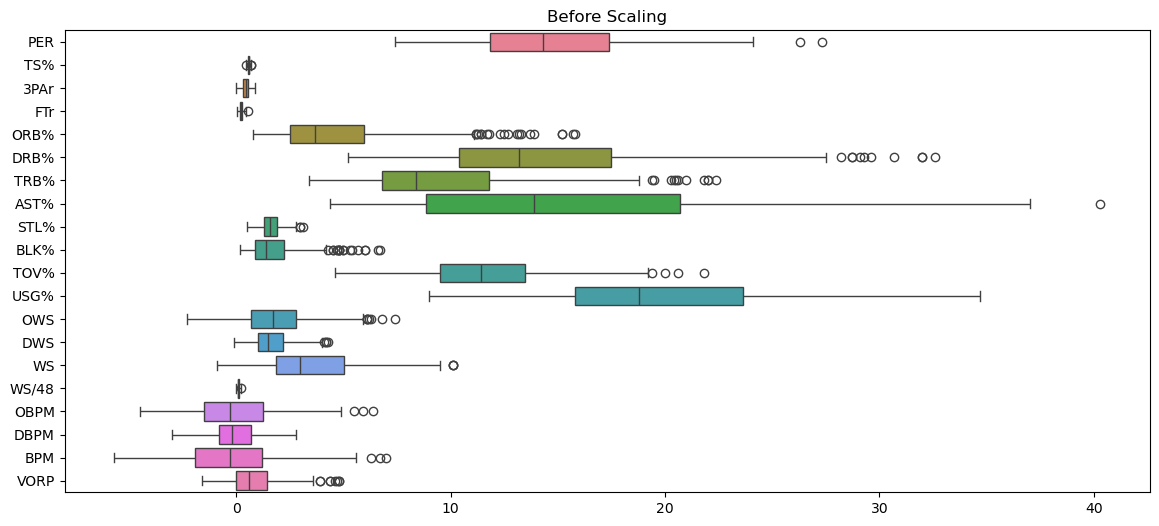

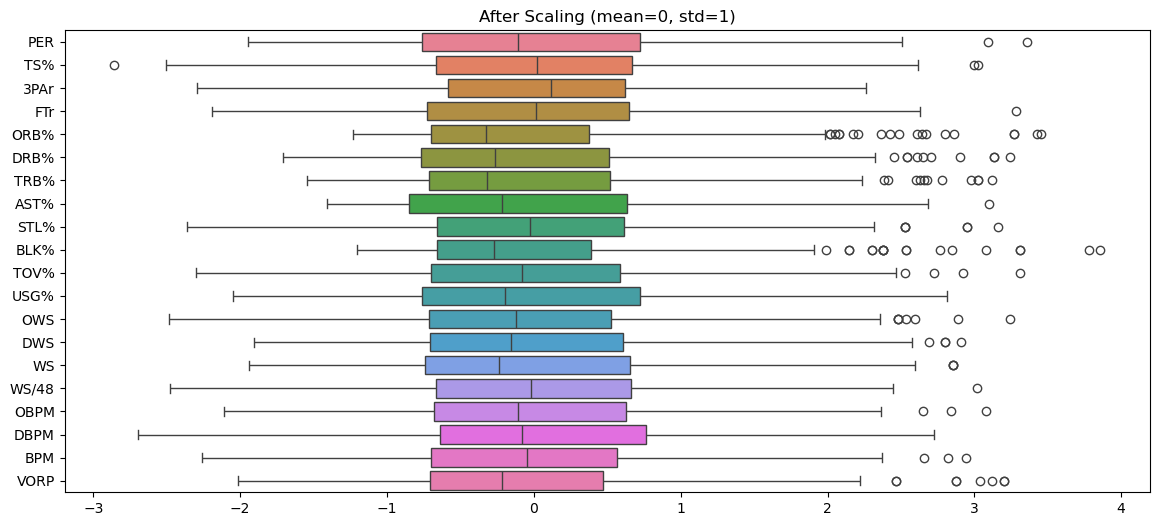

In [59]:
# BEFORE SCALING ---- Features on very different scales
plt.figure(figsize=(14,6))
sns.boxplot(data=X, orient="h")
plt.title("Before Scaling")
plt.show()

# AFTER SCALING ---- reuse X_scaled from earlier
plt.figure(figsize=(14,6))
sns.boxplot(data=X_scaled, orient="h")
plt.title("After Scaling (mean=0, std=1)")
plt.show()

Scaling keeps converts features onto the same scale. This makes sure clustering won’t “think” PER is more important than WS just because it has bigger numbers.

## Dimensionality Reduction (PCA/t-SNE)

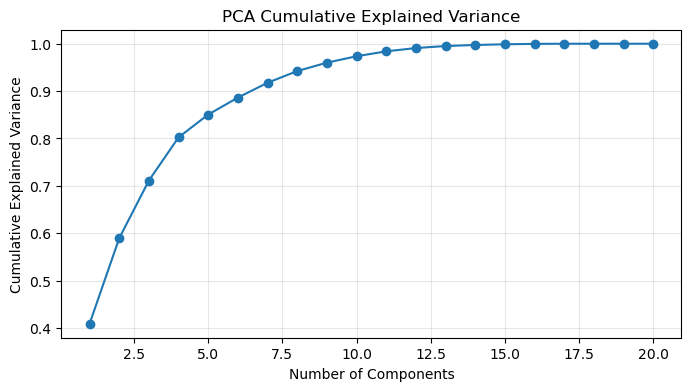

In [60]:
# ---------- PCA: fit + explained variance ----------
pca = PCA(n_components=None, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Scree plot (explained variance ratio)
plt.figure(figsize=(8,4))
evr = pca.explained_variance_ratio_
plt.plot(range(1, len(evr)+1), np.cumsum(evr), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')
plt.grid(True, alpha=0.3)
plt.show()

**PCA transforms the correlated features into a new set of uncorrelated components (principal components).**
**Each PC is a weighted mix of the original features.**
**Since PER% and TSP% were strongly correlated, PCA rolls them into a single component instead of double-counting.**

The first ~10 PCA components capture over 95% of the variance, so reducing from 24 features to 10 gives a simpler, uncorrelated input for clustering while preserving most of the information.

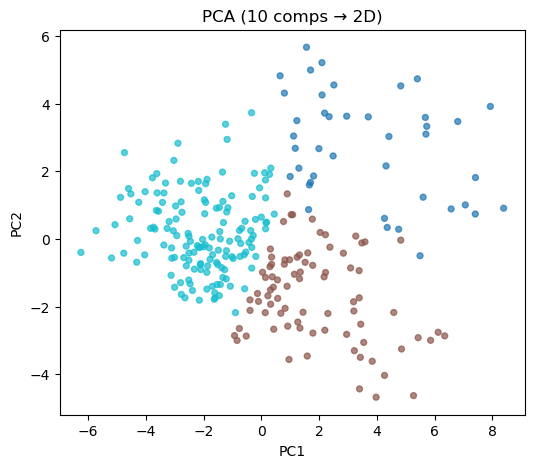

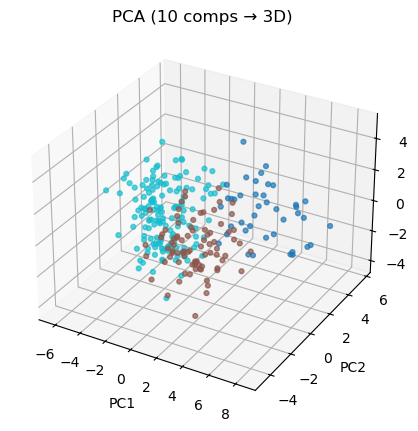

In [61]:
# PCA to 10 comps FROM X_scaled (not from X_pca)
pca = PCA(n_components=10, random_state=42)
X_pca10 = pca.fit_transform(X_scaled)

# KMeans with 3 clusters on that 10-D PCA space
kmeans = KMeans(n_clusters=3, random_state=42, n_init=50)
labels_kmeans = kmeans.fit_predict(X_pca10)

# 2D plot (PC1 vs PC2)
plt.figure(figsize=(6,5))
plt.scatter(X_pca10[:,0], X_pca10[:,1], c=labels_kmeans, cmap="tab10", s=18, alpha=0.7)
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (10 comps → 2D)')
plt.show()

# 3D plot (PC1 vs PC2 vs PC3)
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca10[:,0], X_pca10[:,1], X_pca10[:,2], c=labels_kmeans, cmap="tab10", s=12, alpha=0.7)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('PCA (10 comps → 3D)')
plt.show()



PCA reduces the many stats into a few main patterns. PC1 and PC2 capture the two biggest ways players differ. The scatter plot shows each player in this reduced space — players with similar roles cluster together, and the colors represent the archetypes I found. Three clusters represents three archetypes.

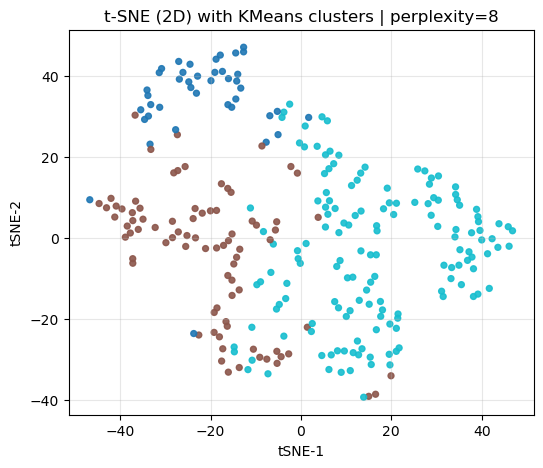

In [62]:
from sklearn.manifold import TSNE

# --- t-SNE setup ---
n = len(X_pca10)   # number of players
perp = int(np.clip(np.sqrt(n)/2, 5, 50))  # rule of thumb for perplexity

tsne = TSNE(
    n_components=2,
    perplexity=perp,
    learning_rate='auto',
    init='pca',
    random_state=42
)
X_tsne = tsne.fit_transform(X_pca10)  # project to 2D

# --- Plot t-SNE with cluster labels ---
plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1],
            c=labels_kmeans, cmap="tab10", s=18, alpha=0.9)
plt.title(f't-SNE (2D) with KMeans clusters | perplexity={perp}')
plt.xlabel('tSNE-1'); plt.ylabel('tSNE-2')
plt.grid(alpha=0.3)
plt.show()

I also used t-SNE as a visualization tool. Unlike PCA, which shows the biggest overall patterns, t-SNE focuses on local similarity — who’s close to who. The t-SNE scatterplot shows that the clusters we found (**Interior Enforcers**, **Star Playmakers** and **Floor Spacers**) actually group tightly together, which supports that the clustering is meaningful.

k=2, silhouette=0.268
k=3, silhouette=0.228
k=4, silhouette=0.176
k=5, silhouette=0.183
k=6, silhouette=0.177
k=7, silhouette=0.166
k=8, silhouette=0.160
k=9, silhouette=0.157


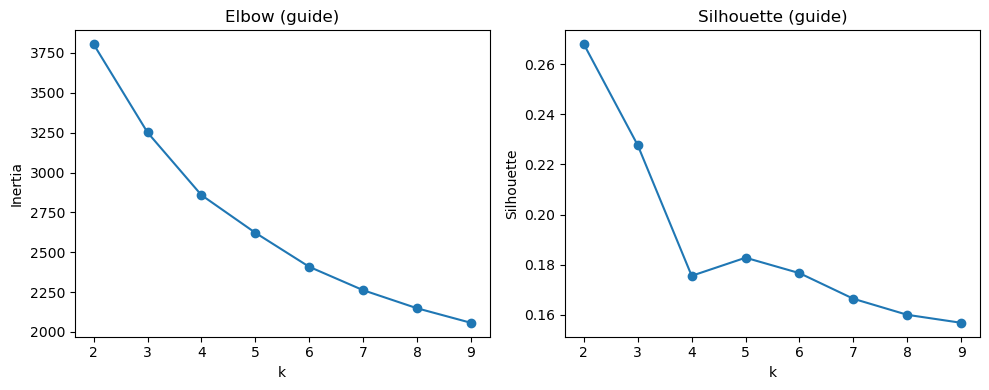


 Best k by silhouette: 2 (score=0.268)


In [63]:
# Range of k values to test
K_range = range(2, 10)
inertias, silhouettes = [], {}

# Loop through each k and compute inertia + silhouette
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=12)
    labels = km.fit_predict(X_pca10)
    inertias.append(km.inertia_)
    silhouettes[k] = silhouette_score(X_pca10, labels)
    print(f"k={k}, silhouette={silhouettes[k]:.3f}")

# Plot elbow (inertia) and silhouette scores
plt.figure(figsize=(10,4))

# Elbow method
plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow (guide)")
plt.xlabel("k")
plt.ylabel("Inertia")

# Silhouette method
plt.subplot(1, 2, 2)
plt.plot(list(silhouettes.keys()), list(silhouettes.values()), marker='o')
plt.title("Silhouette (guide)")
plt.xlabel("k")
plt.ylabel("Silhouette")

plt.tight_layout()
plt.show()

# Pick best k by silhouette score
best_k = max(silhouettes, key=silhouettes.get)
print(f"\n Best k by silhouette: {best_k} (score={silhouettes[best_k]:.3f})")


## Clustering Analysis

### How I Chose the Number of Clusters

I tested different numbers of clusters (k = 2 to 10) and used two guides:

1. **Elbow Method (left plot)**  
   - The line shows how "inertia" (within-cluster error) drops as k increases.  
   - The curve flattens after k=5, meaning adding more clusters doesn’t improve much.  

2. **Silhouette Score (right plot)**  
   - Measures how clearly separated the clusters are (range -1 to 1).  
   - Higher values mean sharper separation.  
   - The best score is at k=2, with k=3 also reasonably strong.  

**Takeaway:**  
- The math says k=2 (and possibly k=3) gives the cleanest split.
- k=3 improves interpretability for basketball roles with only a small silhouette trade-off. It’s a better fit to tell a story. 

In [64]:
# ===============================
# Compare alternative clustering models
# ===============================

from sklearn.cluster import AgglomerativeClustering, DBSCAN

# --- Agglomerative Clustering: range of k values to test ---
K_range = range(2, 10)
silhouettes_hier = {}

for k in K_range:
    hier = AgglomerativeClustering(n_clusters=k)
    labels_hier = hier.fit_predict(X_pca10)
    silhouettes_hier[k] = silhouette_score(X_pca10, labels_hier)
    print(f"k={k}, silhouette={silhouettes_hier[k]:.3f}")

# --- Pick best k by silhouette score ---
best_k_hier = max(silhouettes_hier, key=silhouettes_hier.get)
print(f"\nBest k for Agglomerative by silhouette: {best_k_hier} "
      f"(score={silhouettes_hier[best_k_hier]:.3f})")


# --- DBSCAN ---
db = DBSCAN(eps=2.0, min_samples=10)  # match it tp the same # of components for PCA
labels_db = db.fit_predict(X_pca10)

safe_silhouette(X_pca10, labels_db, "DBSCAN")

k=2, silhouette=0.290
k=3, silhouette=0.259
k=4, silhouette=0.150
k=5, silhouette=0.142
k=6, silhouette=0.126
k=7, silhouette=0.125
k=8, silhouette=0.126
k=9, silhouette=0.124

Best k for Agglomerative by silhouette: 2 (score=0.290)
DBSCAN silhouette: -0.132


np.float64(-0.1318440048619234)

## Comparing Alternative Clustering Models  

After running KMeans, I also tested two other unsupervised models on the PCA-transformed player stats:  

### Agglomerative Clustering  
- Builds clusters step by step, starting with each player as their own group and merging them.  
- Using **k=3**, the silhouette score was **0.259**.  
- This was the **best separation overall**, slightly higher than KMeans.  

###  DBSCAN  
- Does not need a preset number of clusters. Instead, it finds dense “pockets” of players.  
- I set `min_samples=10` to match the 10 PCA components.  
- Result: silhouette score **-0.13** (negative), meaning DBSCAN failed to find useful structure in this dataset.  

### Takeaway  
- **Agglomerative (k=2)** had the strongest separation (**0.29**).  
- **KMeans (k=2)** was close (**0.27**) and gave a simpler, easier-to-interpret split.  
- **DBSCAN** did not perform well, since NBA stats don’t form the kind of “dense blobs” it expects.  

This confirms **both KMeans and Agglomerative were appropriate models** for the data, with Agglomerative showing a slight edge in separation.


### Align PCA and scaled features

In [65]:
# Ensure X_scaled is a DataFrame with the right index/columns
X_scaled_df = (
    X_scaled if isinstance(X_scaled, pd.DataFrame)
    else pd.DataFrame(X_scaled, index=df_no_outliers.index, columns=features)
)

# Ensure X_pca10 is a DataFrame aligned to the SAME rows as X_scaled_df
X_pca10_df = (
    X_pca10 if isinstance(X_pca10, pd.DataFrame)
    else pd.DataFrame(X_pca10, index=X_scaled_df.index, columns=[f"PC{i+1}" for i in range(np.asarray(X_pca10).shape[1])])
)

print("Shapes -> X_scaled_df:", X_scaled_df.shape, " | X_pca10_df:", X_pca10_df.shape)


Shapes -> X_scaled_df: (271, 20)  | X_pca10_df: (271, 10)


**Before any clustering we have to make sure the data tables are properly lined up before clustering**:  

- **X_scaled_df** → the scaled version of our stats, with the same player index and column names.  
- **X_pca10_df** → the PCA projection of those stats, but also forced to keep the same row order and player index as X_scaled_df.  

This way, every row in PCA space still matches the correct player in the original dataset.  
If the shapes or indices don’t line up, cluster labels could get mis-assigned to the wrong players.  

In [66]:
# Final Agglomerative Clustering (k=3 or best_k_hier if computed above)
k = 3  
hier = AgglomerativeClustering(n_clusters=k)
labels_hier = hier.fit_predict(X_pca10_df)

# sanity check: cluster sizes
uniq, cnts = np.unique(labels_hier, return_counts=True)
print("Cluster sizes:", dict(zip(uniq, cnts)))

Cluster sizes: {np.int64(0): np.int64(205), np.int64(1): np.int64(40), np.int64(2): np.int64(26)}


Since Agglomerative Clustering had a better score then kmeans I will proceed to use Agglomerative Clustering.

This is where we **run Agglomerative Clustering** on the PCA-transformed stats.  

We tell Agglomerative how many groups (`k`) to form. The algorithm assigns each player to one of those clusters. The quick “sanity” check shows how many players ended up in each cluster, making sure the split looks reasonable (e.g., no empty groups).  

This is an important step of the project because it creates the cluster labels we’ll use to profile and name player archetypes.  

The output is saying **Cluster 0** has **205** players, **cluster 1** has **40** players, and **Cluster 2** has **26** players.


In [67]:
#  cluster profiles in original feature space
cluster_ids = np.sort(np.unique(labels_hier))
feat_names  = list(X_scaled_df.columns)

Z_means = np.vstack([
    X_scaled_df.iloc[labels_hier == cid].mean(axis=0).values
    for cid in cluster_ids
])
summ = pd.DataFrame(Z_means, index=cluster_ids, columns=feat_names)

This step calculates the **average stat profile** for each cluster.  

- First, it finds the different clusters that Agglomerative  created.  
- Then, for each cluster, it looks at all the players inside and computes their **average z-scores** (how far above or below league average they are) for every stat.  
- Finally, it stores these averages in a table called (`summ`).  

This table makes it easy to see what makes each cluster unique — for example, one group might average high rebounds and blocks, while another averages high shooting efficiency.  

In [68]:
# read the clusters
print("Cluster means (z-scores) — ALL features:")
print(summ.round(2))   

for i, cid in enumerate(cluster_ids):
    row = Z_means[i]
    hi = np.argsort(-row)[:3]
    lo = np.argsort(row)[:3]
    print(f"\nCluster {cid} (n={(labels_hier==cid).sum()})")
    print("  Strongest:", [f"{feat_names[j]}({row[j]:.2f})" for j in hi])
    print("  Weakest:  ", [f"{feat_names[j]}({row[j]:.2f})" for j in lo])


Cluster means (z-scores) — ALL features:
    PER   TS%  3PAr   FTr  ORB%  DRB%  TRB%  AST%  STL%  BLK%  TOV%  USG%  \
0 -0.42 -0.25  0.28 -0.25 -0.26 -0.28 -0.30 -0.12  0.05 -0.22 -0.03 -0.18   
1  1.23  0.89 -1.44  0.93  1.79  1.59  1.78 -0.19 -0.43  1.44  0.20 -0.01   
2  1.38  0.56  0.03  0.54 -0.67 -0.20 -0.38  1.20  0.25 -0.45 -0.08  1.40   

    OWS   DWS    WS  WS/48  OBPM  DBPM   BPM  VORP  
0 -0.36 -0.26 -0.36  -0.38 -0.33 -0.16 -0.35 -0.36  
1  0.80  0.79  0.90   1.27  0.57  0.81  0.84  0.69  
2  1.57  0.82  1.48   1.04  1.70  0.03  1.47  1.78  

Cluster 0 (n=205)
  Strongest: ['3PAr(0.28)', 'STL%(0.05)', 'TOV%(-0.03)']
  Weakest:   ['PER(-0.42)', 'WS/48(-0.38)', 'WS(-0.36)']

Cluster 1 (n=40)
  Strongest: ['ORB%(1.79)', 'TRB%(1.78)', 'DRB%(1.59)']
  Weakest:   ['3PAr(-1.44)', 'STL%(-0.43)', 'AST%(-0.19)']

Cluster 2 (n=26)
  Strongest: ['VORP(1.78)', 'OBPM(1.70)', 'OWS(1.57)']
  Weakest:   ['ORB%(-0.67)', 'BLK%(-0.45)', 'TRB%(-0.38)']



## Justifying archetype names for this project.

This step is about **reading what each cluster actually looks like**.  It prints the **average stat values (z-scores)** for every feature across players in each cluster. It also highlights the **top 3 strongest stats** and **3 weakest stats** per cluster.  

  
This is how we decide what to **call each archetype**: 
- If a cluster is strong in rebounds/blocks but weak in 3P shooting → we name it **"Interior Enforcers"**.  
- If a cluster is strong in playmaking and impact stats → we name it **"Star Playmakers"**.  
- If a cluster is strong in spacing stats like 3PAr but weaker in creation → we call it **"Floor Spacers"**.  

This step gives the **evidence** for assigning the human-readable archetype names.  

In [69]:
name_map = {
    0: "Floor Spacers",
    1: "Interior Enforcers",
    2: "Star Playmakers"
}


This creates a **dictionary (`name_map`)** that tells the computer how to translate cluster numbers (0, 1, 2) into **easy-to-understand archetype names**.  

- Cluster `0` → "Floor Spacers"  
- Cluster `1` → "Interior Enforcers"  
- Cluster `2` → "Star Playmakers"  

Instead of showing clusters as just numbers, this makes the results **readable for humans**. It’s the final step that connects the math (cluster IDs) to basketball roles.  


In [70]:
#  assignments table
assignments = df_no_outliers[['Player','Pos','Team']].copy()
assignments['cluster']   = labels_hier
assignments['archetype'] = assignments['cluster'].map(name_map)

# sanity peek
for c in cluster_ids:
    group = assignments[assignments['cluster'] == c]
    print(f"\n=== Cluster {c}: {name_map[c]} (n={len(group)}) ===")
    print(group.sample(min(5, len(group)), random_state=42).to_string(index=False))



=== Cluster 0: Floor Spacers (n=205) ===
            Player Pos Team  cluster     archetype
Bennedict Mathurin  SF  IND        0 Floor Spacers
   Andrew Nembhard  SG  IND        0 Floor Spacers
     Jose Alvarado  PG  NOP        0 Floor Spacers
     Malik Beasley  SG  DET        0 Floor Spacers
 Immanuel Quickley  PG  TOR        0 Floor Spacers

=== Cluster 1: Interior Enforcers (n=40) ===
           Player Pos Team  cluster          archetype
Jaren Jackson Jr.   C  MEM        1 Interior Enforcers
     Jakob Poeltl   C  TOR        1 Interior Enforcers
   Isaiah Stewart   C  DET        1 Interior Enforcers
      Luke Kornet   C  BOS        1 Interior Enforcers
     Bobby Portis  PF  MIL        1 Interior Enforcers

=== Cluster 2: Star Playmakers (n=26) ===
         Player Pos Team  cluster       archetype
   Devin Booker  SG  PHO        2 Star Playmakers
  Kawhi Leonard  SF  LAC        2 Star Playmakers
Anthony Edwards  SG  MIN        2 Star Playmakers
      Ty Jerome  SG  CLE        2

### This step builds the **final results table (`assignments`)** that links each player to:  

- Their name, position, and team  
- The cluster number they belong to (0, 1, or 2)  
- A clear **archetype name** (like "Interior Enforcers") instead of just a number  

It then prints out a small sample of players from each cluster so you can **quickly sanity-check** if the groupings make sense.  

### What the Output Means  

- **Cluster 0: Floor Spacers (n=148)** → 148 players whose main value is stretching the floor with shooting. Example: Malik Beasley.   
- **Cluster 1:Interior Enforcers (n=40)** → 40 players who dominate inside (rebounds, blocks, finishing). Example: Jaren Jackson Jr.
- **Cluster 2: Star Playmakers (n=26)** → 26 players who drive offense with scoring + playmaking. Example: Devin Booker.  


In Conclusion: this step **translates the math into basketball roles** and shows you if the model’s labeling looks realistic.  

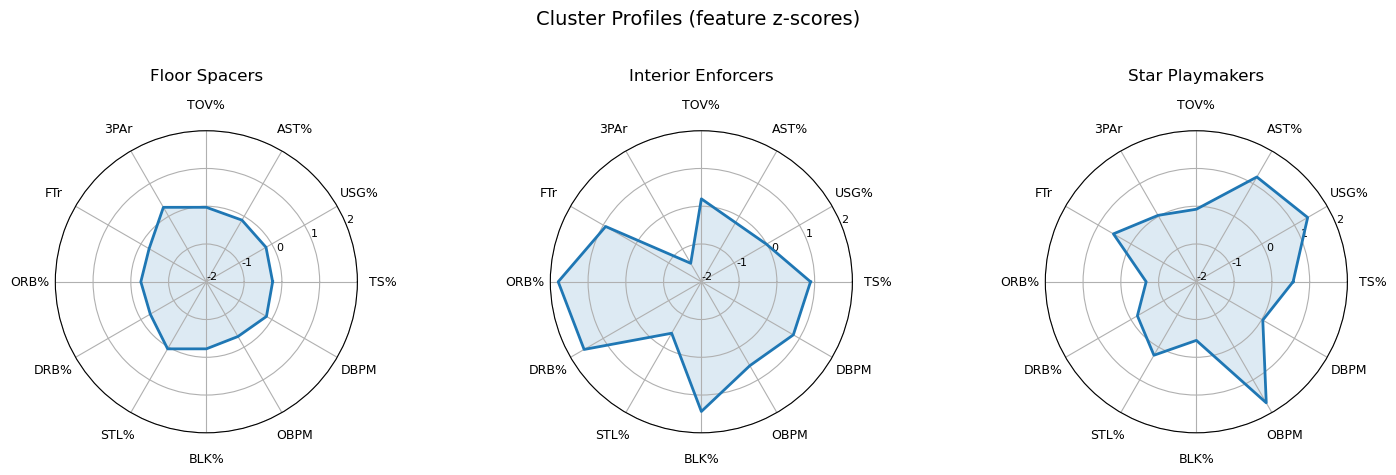

In [71]:
# === Radar charts per cluster (z-score feature profiles) ===
import numpy as np
import matplotlib.pyplot as plt

# 1) Choose which features to show on the radar (order matters)
preferred = ['TS%','USG%','AST%','TOV%','3PAr','FTr','ORB%','DRB%','STL%','BLK%','OBPM','DBPM']

# Keep only features that exist in X_scaled_df
feat_names = list(X_scaled_df.columns)
radar_features = [f for f in preferred if f in feat_names]
if len(radar_features) == 0:
    raise ValueError("None of the preferred radar features are in X_scaled_df columns.")

# 2) Compute mean z-scores per cluster for those features
cluster_ids = np.sort(np.unique(labels_hier))
Z_means_full = np.vstack([
    X_scaled_df.iloc[labels_hier == cid].mean(axis=0).values
    for cid in cluster_ids
])
# index mapping from full feature list to radar_features
idx_map = [feat_names.index(f) for f in radar_features]
Zm = Z_means_full[:, idx_map]  # shape: (K x F for radar)

# 3) Small helper to draw a radar
def radar_chart(ax, values, labels, title):
    F = len(labels)
    angles = np.linspace(0, 2*np.pi, F, endpoint=False)
    vals = np.r_[values, values[0]]   # close loop
    angs = np.r_[angles, angles[0]]

    ax.plot(angs, vals, linewidth=2)
    ax.fill(angs, vals, alpha=0.15)
    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=9)
    ax.tick_params(axis='x', pad=8)
    ax.set_yticks([-2,-1,0,1,2])
    ax.set_yticklabels(['-2','-1','0','1','2'], fontsize=8)
    ax.set_title(title, fontsize=12, y=1.14)

# 4) Plot one radar per cluster
cols = min(3, len(cluster_ids))
rows = int(np.ceil(len(cluster_ids)/cols))
fig = plt.figure(figsize=(5*cols, 4.7*rows))

for i, cid in enumerate(cluster_ids):
    ax = plt.subplot(rows, cols, i+1, projection='polar')
    title = name_map.get(int(cid), f"Cluster {cid}")  # use your archetype names if provided
    radar_chart(ax, Zm[i], radar_features, title)

plt.suptitle("Cluster Profiles (feature z-scores)", fontsize=14, y=0.98)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


### Conclusion  
 NBA players were grouped into three archetypes using unsupervised learning. 
- **Cluster 0: Floor Spacers** – shooters who spread the floor and add offensive balance.  
- **Cluster 1: Interior Enforcers** – bigs who dominate rebounding, shot-blocking, and inside play.  
- **Cluster 2: Star Playmakers** – high-impact players driving team offense and overall efficiency.  

By standardizing stats, reducing redundancy with PCA, and clustering players, we revealed how data can highlight player roles and value beyond the box score.

### Limitations & Next Steps 

**Limitations**
- Roles are based on just one season — injuries, coaching, or team changes can shift how players look.  
- Cutoffs like “800 minutes” or removing extreme outliers are choices I made, not hard rules.  
- The model (Agglomerative Clustering) assumes neat, round groups, but real basketball roles can overlap.  

**Next Steps**
- Test stability by running this across multiple seasons and see if player roles change.  
- Try more flexible models (like Gaussian Mixtures or HDBSCAN) that can handle messier clusters.  
- Add richer data: lineup impact, tracking stats, or contract info to strengthen insights.  
- Build a dashboard so users can type in a player and instantly see their archetype and top comparisons.  